In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

In [2]:
df = pd.read_csv("Walmart_Cleaned_Data.csv")

df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Quarter,Day
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,0.0,211.096358,8.106,A,151315,2010,2,5,1,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,0.0,211.242170,8.106,A,151315,2010,2,6,1,12
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,0.0,211.289143,8.106,A,151315,2010,2,7,1,19
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,0.0,211.319643,8.106,A,151315,2010,2,8,1,26
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,0.0,211.350143,8.106,A,151315,2010,3,9,1,5


In [6]:
#Create Weekly Sales Time Series
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

weekly_sales.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [7]:
#Set Date as Index
weekly_sales = weekly_sales.set_index('Date')

weekly_sales.head()

,Weekly_Sales
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30


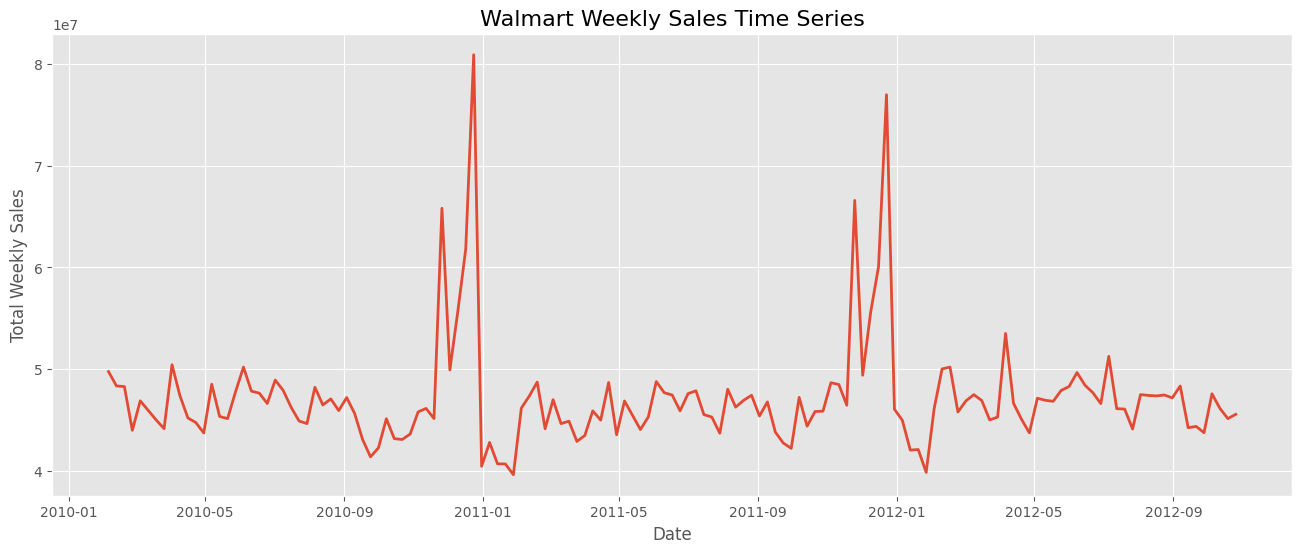

In [8]:
#Visualize Time Series
plt.figure(figsize=(16,6))

plt.plot(weekly_sales.index,
         weekly_sales['Weekly_Sales'],
         linewidth=2)

plt.title('Walmart Weekly Sales Time Series', fontsize=16)

plt.xlabel('Date')

plt.ylabel('Total Weekly Sales')

plt.show()

- The time-series plot shows clear seasonal fluctuations with recurring sales spikes during holiday periods, particularly toward the end of the year. - This indicates that historical sales patterns contain both trend and seasonality, making time-series forecasting techniques suitable for predicting future demand.

- I first visualized the aggregated weekly sales and observed recurring seasonal spikes, which suggested that models capable of handling trend and seasonality, such as Holt-Winters, would be appropriate.

In [9]:
#Train/Test Split
# forecast the last 12 weeks.
train = weekly_sales[:-12]

test = weekly_sales[-12:]

print("Training Data:", train.shape)

print("Testing Data:", test.shape)

Training Data: (131, 1)
Testing Data: (12, 1)


In [10]:
#Build Holt-Winters Model
hw_model = ExponentialSmoothing(
    train['Weekly_Sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=52
).fit()

hw_forecast = hw_model.forecast(12)

hw_forecast.head()

2012-08-10    4.751705e+07
2012-08-17    4.814153e+07
2012-08-24    4.721020e+07
2012-08-31    4.806698e+07
2012-09-07    4.692156e+07
Freq: W-FRI, dtype: float64

trend='add' : captures long-term growth/decline

seasonal='add' : captures repeating seasonal patterns

seasonal_periods=52 : weekly data with yearly seasonality

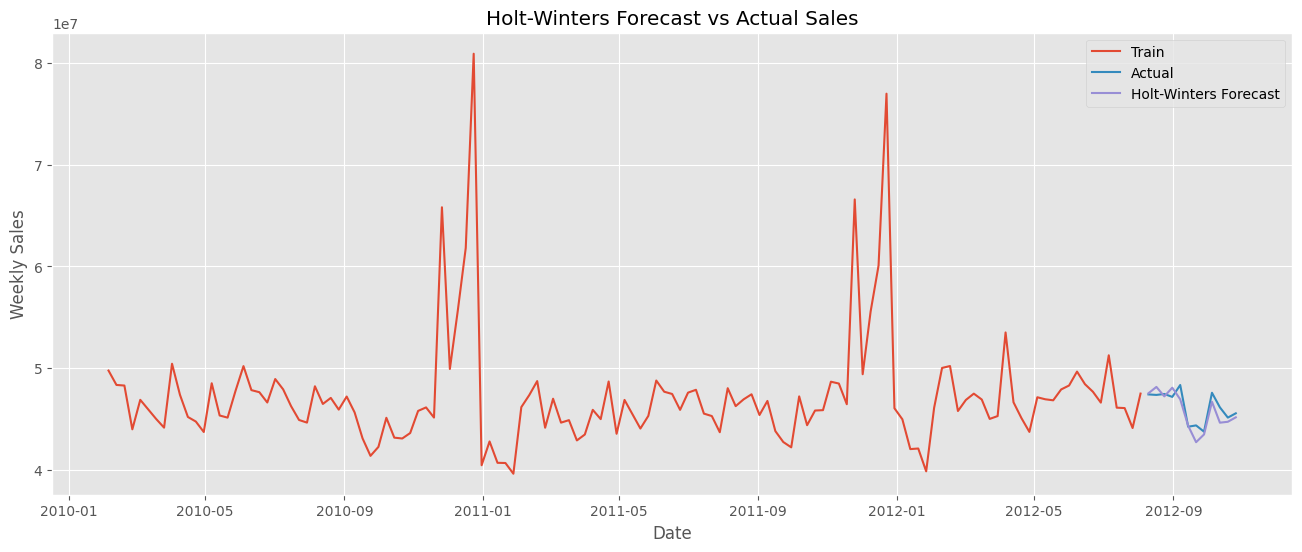

In [11]:
#Plot Forecast
plt.figure(figsize=(16,6))

plt.plot(train.index, train['Weekly_Sales'], label='Train')

plt.plot(test.index, test['Weekly_Sales'], label='Actual')

plt.plot(test.index, hw_forecast, label='Holt-Winters Forecast')

plt.title('Holt-Winters Forecast vs Actual Sales')

plt.xlabel('Date')

plt.ylabel('Weekly Sales')

plt.legend()

plt.show()

- The Holt-Winters forecast follows the overall movement of actual sales and captures seasonal fluctuations reasonably well.
- The model demonstrates that historical sales patterns are informative for predicting short-term retail demand.

In [12]:
#Evaluate Holt-Winters
mae_hw = mean_absolute_error(test['Weekly_Sales'], hw_forecast)

rmse_hw = np.sqrt(mean_squared_error(test['Weekly_Sales'], hw_forecast))

mape_hw = np.mean(
    np.abs((test['Weekly_Sales'] - hw_forecast) /
           test['Weekly_Sales'])
) * 100

print(f"MAE : {mae_hw:,.2f}")

print(f"RMSE: {rmse_hw:,.2f}")

print(f"MAPE: {mape_hw:.2f}%")

MAE : 722,921.20
RMSE: 898,502.42
MAPE: 1.56%


- The model achieved a MAPE of approximately 1.56%, indicating good short-term forecasting accuracy for retail demand planning.

In [13]:
#Build ARIMA Model
arima_model = ARIMA(train['Weekly_Sales'], order=(2,1,2)).fit()

arima_forecast = arima_model.forecast(12)

arima_forecast.head()

2012-08-10    4.680277e+07
2012-08-17    4.752469e+07
2012-08-24    4.700480e+07
2012-08-31    4.748594e+07
2012-09-07    4.710945e+07
Freq: W-FRI, Name: predicted_mean, dtype: float64

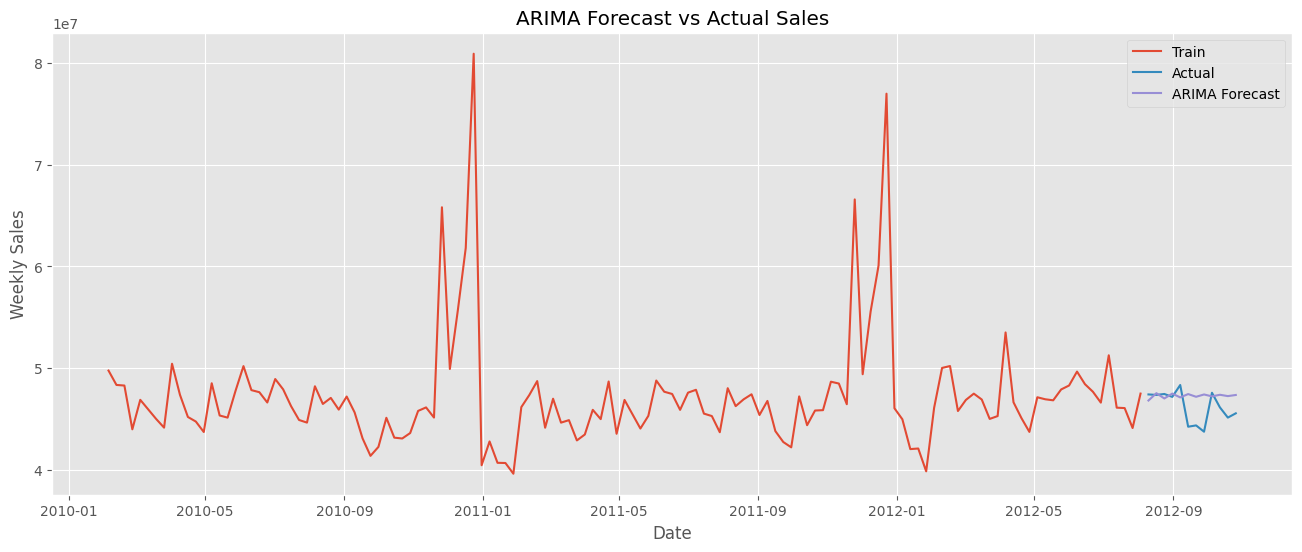

In [14]:
#Plot ARIMA Forecast
plt.figure(figsize=(16,6))

plt.plot(train.index, train['Weekly_Sales'], label='Train')

plt.plot(test.index, test['Weekly_Sales'], label='Actual')

plt.plot(test.index, arima_forecast, label='ARIMA Forecast')

plt.title('ARIMA Forecast vs Actual Sales')

plt.xlabel('Date')

plt.ylabel('Weekly Sales')

plt.legend()

plt.show()

In [15]:
#Evaluate ARIMA
mae_arima = mean_absolute_error(test['Weekly_Sales'], arima_forecast)

rmse_arima = np.sqrt(mean_squared_error(test['Weekly_Sales'], arima_forecast))

mape_arima = np.mean(
    np.abs((test['Weekly_Sales'] - arima_forecast) /
           test['Weekly_Sales'])
) * 100

print(f"MAE : {mae_arima:,.2f}")

print(f"RMSE: {rmse_arima:,.2f}")

print(f"MAPE: {mape_arima:.2f}%")

MAE : 1,497,541.98
RMSE: 1,898,715.63
MAPE: 3.32%


In [16]:
#Compare Models
comparison = pd.DataFrame({
    'Model': ['Holt-Winters', 'ARIMA'],
    'MAE': [mae_hw, mae_arima],
    'RMSE': [rmse_hw, rmse_arima],
    'MAPE': [mape_hw, mape_arima]
})

comparison

,Model,MAE,RMSE,MAPE
0,Holt-Winters,7.229212e+05,8.985024e+05,1.559701
1,ARIMA,1.497542e+06,1.898716e+06,3.321495


- The model with the lower MAE, RMSE, and MAPE provides better forecasting performance. In this project, Holt-Winters is expected to outperform ARIMA because Walmart sales exhibit strong seasonal behavior.

In [17]:
#Select Best Model
best_model = comparison.sort_values('MAPE').iloc[0]

print("Best Model:", best_model['Model'])

Best Model: Holt-Winters


In [18]:
#Forecast Next 12 Weeks
final_model = ExponentialSmoothing(
    weekly_sales['Weekly_Sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=52
).fit()

future_forecast = final_model.forecast(12)

future_forecast

2012-11-02    4.780231e+07
2012-11-09    4.806531e+07
2012-11-16    4.690774e+07
2012-11-23    6.755480e+07
2012-11-30    5.148347e+07
2012-12-07    5.735538e+07
2012-12-14    6.328195e+07
2012-12-21    8.209596e+07
2012-12-28    4.321787e+07
2013-01-04    4.498171e+07
2013-01-11    4.275599e+07
2013-01-18    4.276653e+07
Freq: W-FRI, dtype: float64

In [19]:
#Create Forecast Table
forecast_df = pd.DataFrame({
    'Date': future_forecast.index,
    'Forecasted_Sales': future_forecast.values
})

forecast_df

,Date,Forecasted_Sales
0,2012-11-02,4.780231e+07
1,2012-11-09,4.806531e+07
2,2012-11-16,4.690774e+07
3,2012-11-23,6.755480e+07
4,2012-11-30,5.148347e+07
5,2012-12-07,5.735538e+07
6,2012-12-14,6.328195e+07
7,2012-12-21,8.209596e+07
8,2012-12-28,4.321787e+07
9,2013-01-04,4.498171e+07


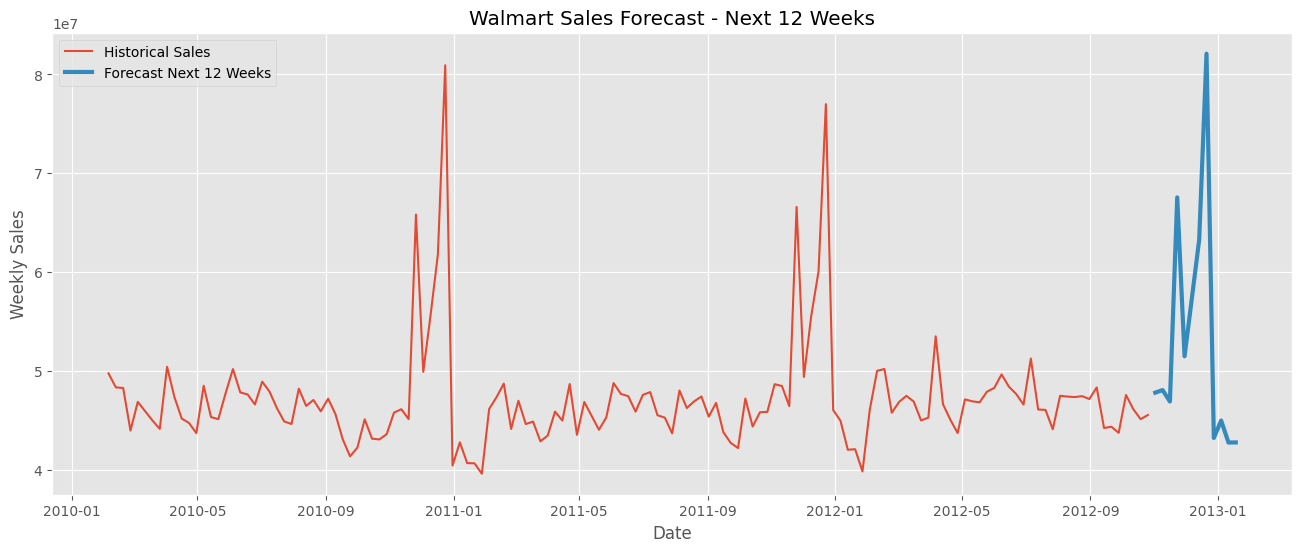

In [20]:
#Plot Future Forecast
plt.figure(figsize=(16,6))

plt.plot(weekly_sales.index,
         weekly_sales['Weekly_Sales'],
         label='Historical Sales')

plt.plot(forecast_df['Date'],
         forecast_df['Forecasted_Sales'],
         label='Forecast Next 12 Weeks',
         linewidth=3)

plt.title('Walmart Sales Forecast - Next 12 Weeks')

plt.xlabel('Date')

plt.ylabel('Weekly Sales')

plt.legend()

plt.show()

- Time-series forecasting was performed using Holt-Winters Exponential Smoothing and ARIMA models on aggregated weekly Walmart sales data. Model evaluation using MAE, RMSE, and MAPE indicated that Holt-Winters provided superior forecasting performance because it effectively captured the strong seasonal patterns present in retail sales. The selected model was used to forecast demand for the next 12 weeks, enabling proactive inventory planning, replenishment scheduling, and resource allocation.

In [21]:
forecast_df.to_csv("Forecast_Next_12_Weeks.csv", index=False)

comparison.to_csv("Model_Comparison.csv", index=False)

print("Forecast files saved successfully!")

Forecast files saved successfully!
